# 1.서울 열린데이터 광장

- 서울시에서 운영하는 공공데이터 포털로, 서울시에서 생성하거나 관리하는 다양한 공공 데이터를 시민과 기업에게 제공하는 플랫폼.
- 연구, 관리, 서비스 제공 등 서울시 시정활동 과정에서 수집된 다양한 데이터가 존재.
- 공공데이터를 쉽게 검색이 가능하고, 확인된 공공데이터를 자유롭게 사용 가능.
- 데이터 활용 지원
    - API 제공: 데이터에 직접 접근할 수 있는 API를 제공하여 프로그램 및 서비스 개발에 활용 가능.
    - 다운로드 기능: 데이터를 엑셀, CSV, JSON 등의 형식으로 다운로드하여 분석 및 연구에 활용 가능.


## 1.1.서울시 지하철호선별 역별 승하차 인원 정보

- 교통카드를 이용한 지하철호선별 역별 승하차인원 정보(일 단위)를 가져온다.

### 1.1.1.데이터 가져오기

- 오픈 API를 사용해 데이터를 가져온다.

In [40]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import urllib.request       # URL 요청을 통해 데이터를 가져오는데 사용
import json                 # json 데이터를 처리하는데 사용

In [41]:
# 인증키와 주소

key = '77636e76526b696e353769536c7759'
start = 1
end = 1000

url = f'http://openapi.seoul.go.kr:8088/{key}/json/CardSubwayStatsNew/{start}/{end}/20260403'

In [ ]:
# 데이터 가져오기
response = urllib.request.urlopen(url)
json_str = response.read().decode('utf-8')
print(json_str)

{"CardSubwayStatsNew":{"list_total_count":620,"RESULT":{"CODE":"INFO-000","MESSAGE":"정상 처리되었습니다"},"row":[{"USE_YMD":"20260403","SBWY_ROUT_LN_NM":"1호선","SBWY_STNS_NM":"서울역","GTON_TNOPE":"94609","GTOFF_TNOPE":"93968","REG_YMD":"20260406"},{"USE_YMD":"20260403","SBWY_ROUT_LN_NM":"1호선","SBWY_STNS_NM":"시청","GTON_TNOPE":"31450","GTOFF_TNOPE":"32177","REG_YMD":"20260406"},{"USE_YMD":"20260403","SBWY_ROUT_LN_NM":"1호선","SBWY_STNS_NM":"종각","GTON_TNOPE":"46450","GTOFF_TNOPE":"46248","REG_YMD":"20260406"},{"USE_YMD":"20260403","SBWY_ROUT_LN_NM":"1호선","SBWY_STNS_NM":"종로3가","GTON_TNOPE":"30070","GTOFF_TNOPE":"27066","REG_YMD":"20260406"},{"USE_YMD":"20260403","SBWY_ROUT_LN_NM":"1호선","SBWY_STNS_NM":"종로5가","GTON_TNOPE":"27360","GTOFF_TNOPE":"26702","REG_YMD":"20260406"},{"USE_YMD":"20260403","SBWY_ROUT_LN_NM":"1호선","SBWY_STNS_NM":"동대문","GTON_TNOPE":"14347","GTOFF_TNOPE":"12963","REG_YMD":"20260406"},{"USE_YMD":"20260403","SBWY_ROUT_LN_NM":"1호선","SBWY_STNS_NM":"신설동","GTON_TNOPE":"17437","GTOFF_TNOPE":"

In [43]:
# 딕셔너리로 변환
json_object = json.loads(json_str)
print(type(json_object))

<class 'dict'>


In [ ]:
json_object

In [ ]:
# 데이터프레임으로 변환
subway = pd.json_normalize(json_object['CardSubwayStatsNew']['row'])
subway.info

In [46]:
# 분석을 위해 승하차 인원 컬럼을 숫자형으로 변환
subway[['GTON_TNOPE','GTOFF_TNOPE']] = subway[['GTON_TNOPE','GTOFF_TNOPE']].astype(int)

subway.head()

,USE_YMD,SBWY_ROUT_LN_NM,SBWY_STNS_NM,GTON_TNOPE,GTOFF_TNOPE,REG_YMD
0,20260403,1호선,서울역,94609,93968,20260406
1,20260403,1호선,시청,31450,32177,20260406
2,20260403,1호선,종각,46450,46248,20260406
3,20260403,1호선,종로3가,30070,27066,20260406
4,20260403,1호선,종로5가,27360,26702,20260406


In [47]:
subway.tail()

,USE_YMD,SBWY_ROUT_LN_NM,SBWY_STNS_NM,GTON_TNOPE,GTOFF_TNOPE,REG_YMD
615,20260403,신림선,당곡,5775,5469,20260406
616,20260403,신림선,신림,2622,3215,20260406
617,20260403,신림선,서원,4258,3577,20260406
618,20260403,신림선,서울대벤처타운,12308,10794,20260406
619,20260403,신림선,관악산(서울대),3788,3583,20260406


**데이터셋 정보**
- USE_YMD: 사용일자
- SBWY_ROUT_LN_NM: 호선명
- SBWY_STNS_NM: 역명
- GTON_TNOPE: 승차총승객수
- GTOFF_TNOPE:하차총승객수
- REG_YMD: 등록일자

### 1.1.2.데이터 분석

- 간단한 전처리와 분석을 해봅시다.

In [48]:
# 라이브러리 불러오기
import matplotlib.pyplot as plt


**1) 데이터 탐색 및 전처리**

- 열 이름, 데이터 형식 등 열 정보 확인

In [62]:
subway.info()

<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   USE_YMD          620 non-null    str  
 1   SBWY_ROUT_LN_NM  620 non-null    str  
 2   SBWY_STNS_NM     620 non-null    str  
 3   GTON_TNOPE       620 non-null    int64
 4   GTOFF_TNOPE      620 non-null    int64
 5   REG_YMD          620 non-null    str  
dtypes: int64(2), str(4)
memory usage: 29.2 KB


- 기초통계정보 확인

In [50]:
subway.describe()
# GTON 승차 고객 GTOFF 하차 고객

,GTON_TNOPE,GTOFF_TNOPE
count,620.000000,620.000000
mean,14536.075806,14477.580645
std,14306.448845,14664.583117
min,1.000000,0.000000
25%,5273.500000,5052.750000
50%,10569.000000,10025.000000
75%,19050.250000,19150.750000
max,139874.000000,141806.000000


**2) 승차 인원 TOP 10**

- 승차 인원이 가장 많은 역 TOP 10을 추출하여 **subway_top10** 데이터프레임을 만듭니다.
- 정렬 결과로 어긋난 순서의 인덱스를 깔끔하게 초기화합니다.
- 승차 인원 TOP 10을 막대그래프로 시각화합니다.

In [51]:
# 라이브러리 불러오기
import matplotlib.pyplot as plt


In [52]:
subway_top10 = subway.sort_values(by = 'GTON_TNOPE', ascending=False).head(10)
subway_top10

,USE_YMD,SBWY_ROUT_LN_NM,SBWY_STNS_NM,GTON_TNOPE,GTOFF_TNOPE,REG_YMD
25,20260403,2호선,잠실(송파구청),139874,141806,20260406
31,20260403,2호선,강남,98507,97435,20260406
0,20260403,1호선,서울역,94609,93968,20260406
48,20260403,2호선,홍대입구,87730,96404,20260406
41,20260403,2호선,구로디지털단지,68702,67684,20260406
28,20260403,2호선,삼성(무역센터),68478,68479,20260406
29,20260403,2호선,선릉,68104,59820,20260406
20,20260403,2호선,성수,66445,71349,20260406
39,20260403,2호선,신림,65011,63627,20260406
11,20260403,2호선,을지로입구,63681,65238,20260406


In [54]:
# 한글폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

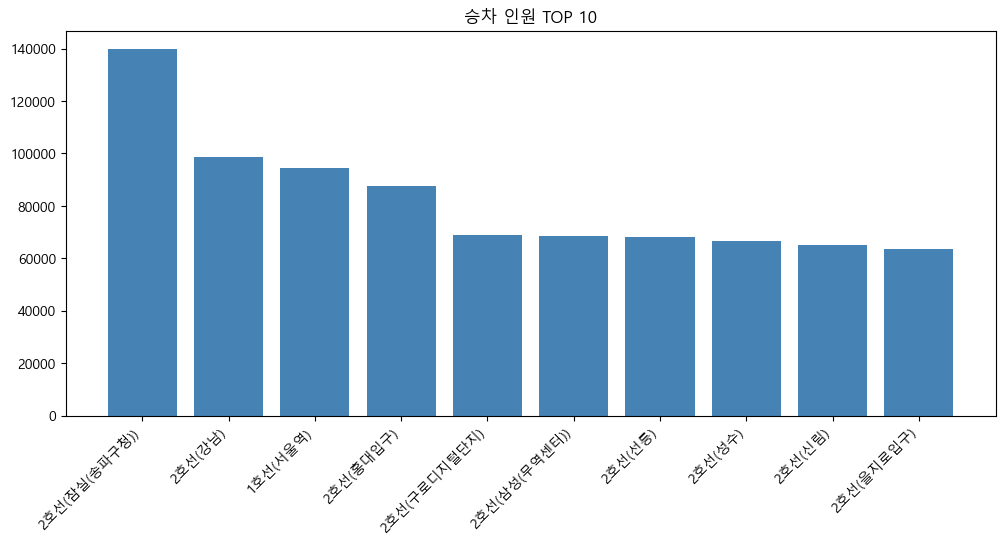

In [56]:
# 막대 그래프
plt.figure(figsize=(12,5))
labels = subway_top10['SBWY_ROUT_LN_NM'] + '(' + subway_top10['SBWY_STNS_NM'] + ')'
plt.bar(labels, subway_top10['GTON_TNOPE'], color = 'steelblue')
plt.title('승차 인원 TOP 10')
plt.xticks(rotation=45, ha='right')
plt.show()


**3) 승차 인원 BOTTOM 10**

- 승차 인원이 가장 적은 역 BOTTOM 10을 추출해 **subway_bottom10** 데이터프레임을 만듭니다.
- 정렬 결과로 어긋난 순서의 인덱스를 깔끔하게 초기화합니다.
- 승차 인원 BOTTOM 10을 막대그래프로 시각화합니다.

In [59]:
subway_bottom10 = subway.sort_values(by = 'GTON_TNOPE', ascending=True).head(10)
subway_bottom10

,USE_YMD,SBWY_ROUT_LN_NM,SBWY_STNS_NM,GTON_TNOPE,GTOFF_TNOPE,REG_YMD
482,20260403,6호선,신내,1,0,20260406
335,20260403,경의선,검암,1,0,20260406
334,20260403,경의선,김포공항,1,0,20260406
269,20260403,일산선,지축,1,0,20260406
448,20260403,6호선,연신내,2,0,20260406
240,20260403,분당선,복정,4,0,20260406
333,20260403,경의선,운천,4,3,20260406
192,20260403,경원선,창동,5,0,20260406
72,20260403,3호선,충무로,7,0,20260406
332,20260403,경의선,임진강,11,4,20260406


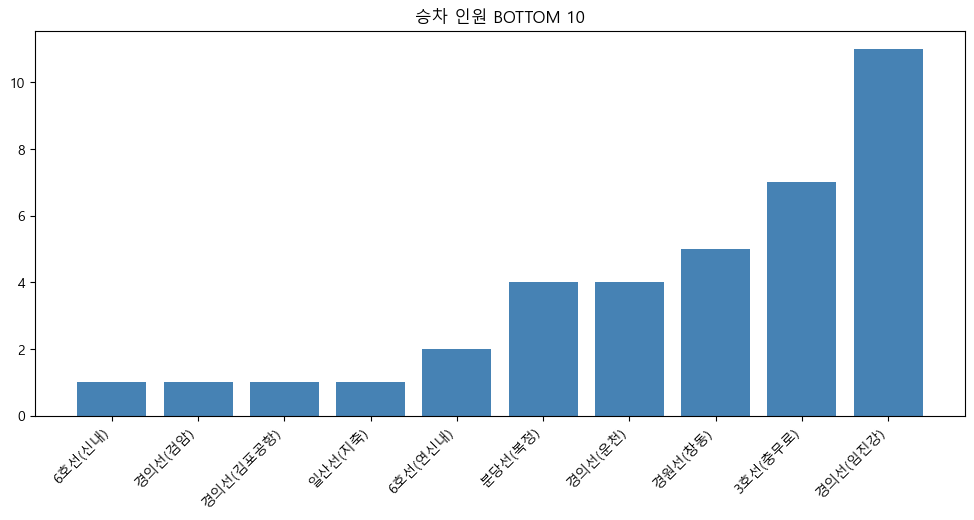

In [61]:
# 막대 그래프
plt.figure(figsize=(12,5))
labels = subway_bottom10['SBWY_ROUT_LN_NM'] + '(' + subway_bottom10['SBWY_STNS_NM'] + ')'
plt.bar(labels, subway_bottom10['GTON_TNOPE'], color = 'steelblue')
plt.title('승차 인원 BOTTOM 10')
plt.xticks(rotation=45, ha='right')
plt.show()
